In [1745]:
import numpy as np
import matplotlib.pyplot as plt
import random as r
import time
from matplotlib import colors
import copy
import matplotlib.animation as animation
from matplotlib import rc

In [1746]:
class Person():
    def __init__(self, Extrovert, mean_steps, variance, name = "Person", ph=0, ps=0, *args):
        """
        Extrovert (Boolean variable): If True tends to move a lot, otherwise is more likely to stay still\n
        mean_steps: The mean number of steps that they like to take\n
        variance: Number that regulates how "diligent" they are, so it is the variance related to mean_steps \n
        and also tells how likely they will follow containment rules\n
        name: You can give a name to this Person\n
        ph: probability to heal 
        ps: probability to get sick 
        """

        if not (type(Extrovert) is bool) and not (type(Extrovert) is np.bool):
            raise TypeError("Extrovert must be True or False")
        if mean_steps < 0 or variance < 0:
            mean_steps, variance = -mean_steps, -variance

        self.__characteristics = {"Extrovert": Extrovert, "Outdoorry": mean_steps, "Diligent": variance}

        #status can be 1 [sane], 2 [infected], 3 [dead]
        self.__status = 1

        #genes mantain the information about their resistance to illnessess
        rec = r.uniform(0,0.5)
        self.__genes = {"Recovery": rec, "Die": r.uniform(0, 0.5 - rec), "Sick": r.uniform(0,1)}
        if ph!=0:
            self.__genes["Recovery"] = ph
            self.__genes["Die"] = 1-ph
        if ps!=0:
            self.__genes["Sick"] = ps

        del rec
        self.__name = name

    def __str__(self):
        """Returns the person's stats"""
        if self.__characteristics["Extrovert"]:
            return f"{self.__name} is extrovert and likes to take {self.__characteristics["Outdoorry"]} steps. \nTheir probability to recover is {self.__genes["Recovery"]}, to die is {self.__genes["Die"]} and to get sick is {self.__genes["Sick"]}."
        else:
            return f"{self.__name} is introvert and likes to take {self.__characteristics["Outdoorry"]} steps. \nTheir probability to recover is {self.__genes["Recovery"]}, to die is {self.__genes["Die"]} and to get sick is {self.__genes["Sick"]}."
        
    def get_status(self, Values = False): #Values should be false if you desire the string interpretation of status
        if not Values:
            status = {1: "sane", 2: "ill", 3: "dead"}
            return status[self.__status]
        else:
            return self.__status
    
    def set_status(self, status=2): #usually they'll get sick, so by default I update to sick
        self.__status = status
    
    def get_character(self):
        return self.__characteristics

    def get_genes(self):
        return self.__genes
    
    def increase_immunity(self):
        self.__genes["Sick"] = self.__genes["Sick"]*0.5 #I decrease their probability to become sick again
    
    def increase_weakness(self):
        self.__genes["Sick"] += self.__genes["Sick"]*0.05

In [1747]:
class World():
    def __init__(self, L, N, d, mu=0, sigma=0, ph=0, ps=0, p_ext=0.5, *args):
        """
        Initialize the world: \n
        L: Side length of the world \n
        N: Number of people in the world\n
        d: distance at which an individual can be infected\n
        \n
        The following can be left out, default settings will be used:\n
        mu: mean value of the gaussian for steps taken\n
        sigma: std of the gaussian for the steps taken\n
        ph: probability to heal\n
        ps: probability to get sick once in range\n
        p_ext: probability for a person to be extrovert; (1-p_ext) introvert\n
        \n
        Default settings:\n
        mu: will be different for all walkers, randomly selected in the interval [L*0.001, L*0.02]\n
        sigma: will be different for all walkers, randomly selected in the interval [L*0.0001, L*0.005]\n
        ph: different for all walkers and randomly selected in the interval [0, 0.5]\n
        ps: different for all walkers and randomly selected in the interval [0, 1]\n

        """

        if L*L < N:
            raise ValueError("There are too many people or too few spots in the world!")
        if ph>1 or ps>1 or p_ext>1:
            raise ValueError("Proabilities can't be higher than one")

        self.__d = d
        if d<0:
            self.__d=-d
        self.__L = L
        self.__N = N
            
        self.__world = np.zeros(shape=(L,L)) #generate the world's structure
        self.__world_history = [] #contains the evolution of the epidemic in the world
        self.__bar = [] #contains the history of healthy, ill, dead people

        self.__positions = set()
        while(self.__positions.__len__() != N):
            self.__positions.add((r.randint(0, L-1), r.randint(0, L-1)))
        if mu == 0 or sigma == 0: 
            self.__positions = np.append([[Person(Extrovert=np.random.choice([True, False], p=[p_ext,1-p_ext]), mean_steps=r.uniform(self.__L*0.001,self.__L*0.02), variance=r.uniform(self.__L*0.0001,self.__L*0.005), ph=ph, ps=ps)] for i in range(N)], (list(self.__positions)), axis=1)
        else:
            self.__positions = np.append([[Person(Extrovert=np.random.choice([True, False], p=[p_ext,1-p_ext]), mean_steps=mu, variance=sigma, ph=ph, ps=ps)] for i in range(N)], (list(self.__positions)), axis=1)


        for i, j, k in  self.__positions:
            self.__world[j,k] = i.get_status(True)

    def plot(self):
        """Returns the fig and plot parameters in case you want to do an animation"""
        colours = ["white", "green", "orange", "red"]
        cmap = colors.ListedColormap(colours)
        bounds=[0,1,2,3,4]
        norm = colors.BoundaryNorm(bounds, cmap.N)     

        fig = plt.figure(figsize=(10,5))

        ax = fig.add_subplot(1,2,1)
        ax.set_title("Positions of all individuals")
        image = ax.imshow((self.__world),interpolation='nearest', origin='lower', cmap=cmap,norm=norm)
        ax.set_xlim(-.5, self.__L-.5)
        ax.set_ylim(-.5, self.__L-.5)
        ax.set_xlabel("x-axis")
        ax.set_ylabel("y-axis")

        ax2 = fig.add_subplot(1,2,2)
        ax2.set_title("Population conditions")
        bars = ax2.bar([1,2,3], self.__bar[-1], color=["green", "orange", "red"])
        ax2.set_xlabel("Status")
        ax2.set_ylabel("Population")
        ax2.set_xticks([1,2,3], ["sane", "ill", "dead"])
        ax2.set_ylim(0, self.__N*1.1)
        plt.show()
        return fig, image, bars
    
    def start_epidemic(self):
        if not 2 in self.__world:
            self.__positions[r.randint(0,self.__N-1), 0].set_status()
            self.update_world()
        
    def update_world(self):
        """Updates the graphic representation of the world, notce that two individuals can be in the same spot (only one will be viewed)"""
        self.__world = np.zeros(shape=(self.__L,self.__L)) #For now i leave it like this, maybe in the future I'll improve the code 
        for i,j,k in self.__positions:
            self.__world[j,k] = i.get_status(True)
        statistics = [i.get_status(True) for i, *_ in self.__positions]
        self.__world_history.append(self.__world)
        self.__bar.append([statistics.count(1), statistics.count(2), statistics.count(3)])

    def time_update(self): 
        """A day passes, all walkers move accordingly and they can heal/die or get infected. """
        for i in range(self.__N):
            if self.__positions[i, 0].get_status(True) != 3: #I ignore the ones that are dead
                temp_char = self.__positions[i, 0].get_character()
                if temp_char["Extrovert"]: #If extrovert, they're more likely to move
                    move_x, move_y = np.random.choice([True, False], p = [0.7, 0.3]), np.random.choice([True, False], p = [0.7, 0.3])
                    move_back_or_forward = r.choice([1,-1])
                else:
                    move_x, move_y = np.random.choice([True, False], p = [0.3, 0.7]), np.random.choice([True, False], p = [0.3, 0.7])
                    move_back_or_forward = r.choice([1,-1])

                if move_x:
                    self.__positions[i, 1] = (self.__positions[i, 1] + move_back_or_forward*int(r.normalvariate(temp_char["Outdoorry"], temp_char["Diligent"])))%self.__L
                if move_y:
                    self.__positions[i, 2] = (self.__positions[i, 2] + move_back_or_forward*int(r.normalvariate(temp_char["Outdoorry"], temp_char["Diligent"])))%self.__L
        
        L=self.__L
        temp_positions = copy.deepcopy(self.__positions) #Variable used to not consider new infected individuals as carriers during the day

        for i in range(self.__N):
            if temp_positions[i][0].get_status(True) == 2: #I check if they're infected
                [j.set_status(2) for j, k, l in self.__positions if (j.get_status(True) == 1 and j != i) and (j.get_genes()["Sick"] > r.uniform(0,1) and (np.linalg.norm(np.array([[k,l], [k+L, l], [k-L,l], [k,l+L], [k, l-L], [k+L, l+L], [k-L, l-L], [k+L, l-L], [k-L, l+L]])-list(self.__positions[i,1:3]), axis=1) < self.__d).any())] #I try to make 'em sick
                #All the [k+L, l-L...] are needed in order to consider all possible distances in the periodic boundary condition lattice
        
        for i in range(self.__N):
            if temp_positions[i][0].get_status(True) == 2: #I check if the old infectors will heal or die
                temp_rand = r.uniform(0,1)
                if temp_positions[i][0].get_genes()["Die"] > temp_rand:
                    self.__positions[i,0].set_status(3)
                elif temp_positions[i][0].get_genes()["Die"] < temp_rand and temp_positions[i][0].get_genes()["Die"] + temp_positions[i][0].get_genes()["Recovery"] > temp_rand:
                    self.__positions[i,0].set_status(1)
                    self.__positions[i,0].increase_immunity()
        
        [i.increase_weakness() for i, *_ in self.__positions if i.get_status(True) == 1] #Increase the weakness of those who ain't been infected

        del temp_positions
        self.update_world()

    def get_world_history(self):
        return self.__world_history, self.__bar 

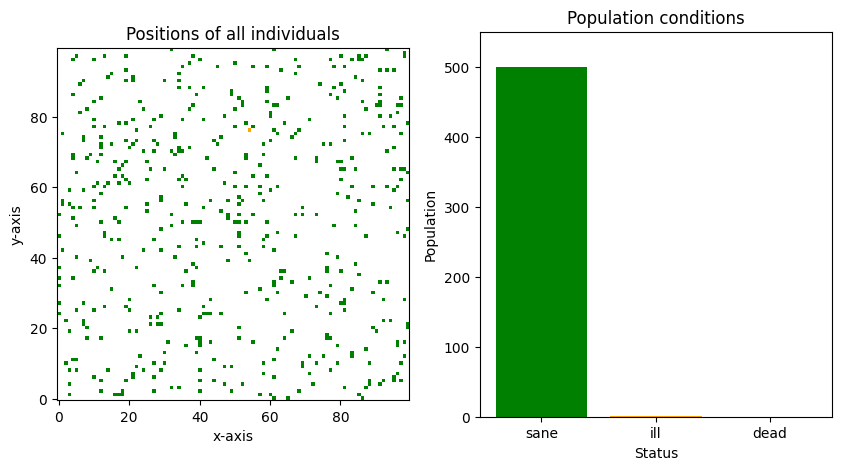

In [1776]:
N=500
L=100
d=7
mu=10
sigma=3
ph=0
ps=0.99
p_ext = 1

#world = World(L, N, d, mu, sigma, ph, ps, p_ext)
world = World(L, N, d)
world.start_epidemic()
fig, im, bar = world.plot()

In [1777]:
[world.time_update() for i in range(100)]
world_history, pop_history = world.get_world_history()

def animate(i):
    im.set_data(world_history[i])
    for j in range(3):
        bar[j].set_height(pop_history[i][j])


anim = animation.FuncAnimation(fig, animate, np.arange(100))
rc('animation', html='jshtml')
anim

Idee: 
- Fai che la diligenza sia parametro anche di isolamento
